# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Estrada Sanchez Rodolfo

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Nota: 
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [5]:
import pandas as pd

In [6]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns

In [8]:
df = pd.read_csv("ventas-por-factura.csv")

In [9]:
df

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"
...,...,...,...,...,...,...
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,"720,00"
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,"298,78"
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,"1488,00"


In [10]:
df.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [12]:
#valores nulos
df.isnull().sum()

N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0
dtype: int64

In [13]:
#Outliers (Negativos o fuera de rango)
df["Cantidad"] = pd.to_numeric(df["Cantidad"], errors="coerce")

df["Monto"] = (
    df["Monto"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["Monto"] = pd.to_numeric(df["Monto"], errors="coerce")

In [14]:
outliers_negativos = df[(df["Cantidad"] < 0) | (df["Monto"] < 0)]


In [15]:
outliers_negativos

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,-1.45
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,-9.25
16,542418,1/27/2021 17:39:00,NaN,United Kingdom,-17,0.00
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,-1.95
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,-16.85
...,...,...,...,...,...,...
25943,C557061,6/16/2021 14:55:00,14895.0,United Kingdom,-5,-14.75
25944,C562147,8/3/2021 10:47:00,16180.0,United Kingdom,-7,-18.35
25947,C553519,5/17/2021 14:16:00,18218.0,United Kingdom,-2,-9.90
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,-12.70


In [16]:
#identificar datos invalidos
datos_invalidos = df[
    (df["Cantidad"].isnull()) |
    (df["Monto"].isnull()) |
    (df["Fecha de factura"].isnull()) |
    (df["ID Cliente"].isnull())
]

In [17]:
datos_invalidos

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
11,539736,12/21/2020 15:18:00,NaN,United Kingdom,143,1172.46
12,537823,12/8/2020 14:25:00,NaN,United Kingdom,1484,6073.71
16,542418,1/27/2021 17:39:00,NaN,United Kingdom,-17,0.00
21,550759,4/20/2021 12:09:00,NaN,United Kingdom,-7,0.00
23,556427,6/10/2021 13:23:00,NaN,United Kingdom,92,435.69
...,...,...,...,...,...,...
25930,539300,12/16/2020 17:31:00,NaN,United Kingdom,38,72.59
25932,565303,9/2/2021 12:17:00,NaN,Unspecified,258,286.85
25937,543533,2/9/2021 13:00:00,NaN,United Kingdom,155,1001.27
25939,C572450,10/24/2021 12:35:00,NaN,United Kingdom,-2,-278.15


In [18]:
#- Facturas canceladas ( identificadas con la letra c)
facturas_canceladas = df[df["N° de factura"].astype(str).str.startswith("C")]

In [19]:
facturas_canceladas

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,-1.45
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,-9.25
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,-1.95
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,-16.85
22,C547309,3/22/2021 11:17:00,17416.0,United Kingdom,-12,-45.00
...,...,...,...,...,...,...
25939,C572450,10/24/2021 12:35:00,NaN,United Kingdom,-2,-278.15
25943,C557061,6/16/2021 14:55:00,14895.0,United Kingdom,-5,-14.75
25944,C562147,8/3/2021 10:47:00,16180.0,United Kingdom,-7,-18.35
25947,C553519,5/17/2021 14:16:00,18218.0,United Kingdom,-2,-9.90


In [20]:
#identificar facturas duplicadas
duplicados = df[df.duplicated()]

In [21]:
duplicados

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
7626,568403,9/27/2021 10:35:00,NaN,United Kingdom,-3,0.00
9728,C581390,12/8/2021 13:13:00,13081.0,United Kingdom,-13,-15.85
11263,568417,9/27/2021 11:10:00,14911.0,EIRE,202,776.30
12533,C581384,12/8/2021 13:06:00,17673.0,United Kingdom,-2,-6.90
13011,568423,9/27/2021 11:24:00,17061.0,United Kingdom,118,573.40
13054,568387,9/27/2021 10:04:00,13704.0,United Kingdom,340,422.32
15861,568384,9/27/2021 9:46:00,12748.0,United Kingdom,1,0.00
18795,C581323,12/8/2021 11:53:00,14442.0,Channel Islands,-1,-4.25
22578,C581330,12/8/2021 11:57:00,15877.0,United Kingdom,-125,-52.50
25704,568404,9/27/2021 10:36:00,NaN,United Kingdom,-17,0.00


In [22]:
#- Problemas de formato o tipo de datos (Fechas o Monto)
df["Fecha de factura"] = pd.to_datetime(df["Fecha de factura"], errors="coerce")

In [23]:
df.dtypes

N° de factura                  str
Fecha de factura    datetime64[us]
ID Cliente                 float64
País                           str
Cantidad                     int64
Monto                      float64
dtype: object

In [24]:
df[df["Fecha de factura"].isnull()]

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto


In [25]:
#Limpiar el dataset
df_limpio = df.copy()

In [26]:
df_limpio = df_limpio.dropna()

In [27]:
df_limpio = df_limpio[~df_limpio["N° de factura"].astype(str).str.startswith("C")]

In [28]:
df_limpio = df_limpio[df_limpio["Cantidad"] > 0]

In [29]:
df_limpio = df_limpio[df_limpio["Monto"] > 0]

In [30]:
df_limpio = df_limpio.drop_duplicates()

In [31]:
df_limpio

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,2021-03-30 16:14:00,15528.0,United Kingdom,123,229.33
1,575767,2021-11-11 11:11:00,17348.0,United Kingdom,163,209.73
3,549106,2021-04-06 12:08:00,17045.0,United Kingdom,1,39.95
4,573112,2021-10-27 15:33:00,16416.0,United Kingdom,357,344.83
5,576630,2021-11-16 08:38:00,13816.0,Germany,91,199.98
...,...,...,...,...,...,...
25945,579252,2021-11-28 16:47:00,17450.0,United Kingdom,432,1034.40
25946,574908,2021-11-07 15:37:00,16009.0,United Kingdom,28,82.76
25949,553060,2021-05-13 10:44:00,15826.0,United Kingdom,488,720.00
25950,577049,2021-11-17 13:58:00,17397.0,United Kingdom,104,298.78


In [32]:
df_limpio.to_csv("ventas_limpias.csv", index=False)

JUSTIFICACION
Se eliminaron los registros con valores nulos porque afectan la confiabilidad del análisis, especialmente cuando falta el ID del cliente. También se eliminaron las facturas canceladas, ya que representan operaciones anuladas y no deben considerarse como ventas reales.

Los valores negativos en cantidad y monto fueron tratados como datos inválidos dentro del análisis de ventas, debido a que pueden representar devoluciones, cancelaciones o errores de captura. Además, se corrigió el formato del monto, cambiando la coma decimal por punto decimal para poder convertirlo correctamente a tipo numérico.

Finalmente, se eliminaron registros duplicados para evitar contar dos veces la misma operación y generar resultados incorrectos.

GIGO
si se entrenara un modelo o se hiciera un análisis con facturas canceladas, montos negativos o clientes sin identificar, las conclusiones podrían ser engañosas. Por eso es importante limpiar y transformar el dataset antes de analizarlo o usarlo en modelos de aprendizaje automático.

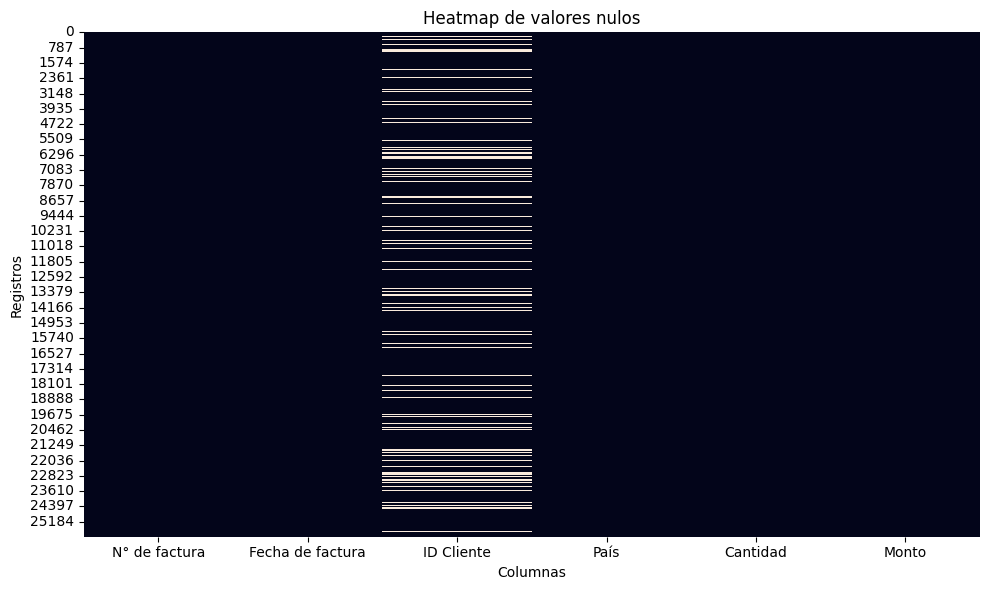

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Heatmap de valores nulos")
plt.xlabel("Columnas")
plt.ylabel("Registros")
plt.tight_layout()
plt.show()

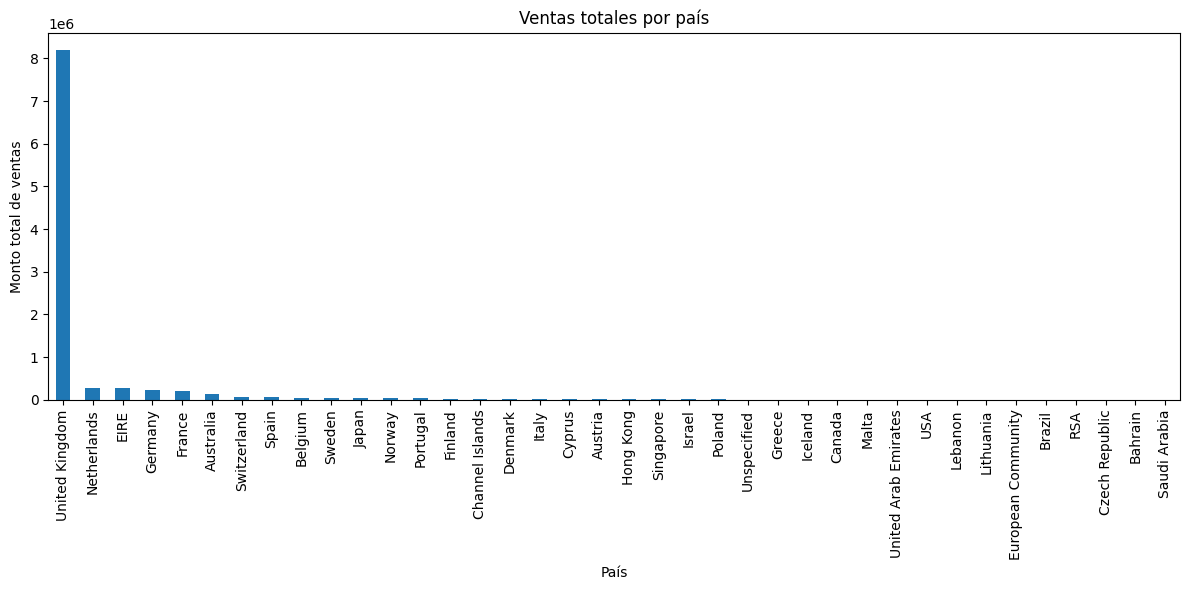

In [34]:
ventas_pais = df.groupby("País")["Monto"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
ventas_pais.plot(kind="bar")
plt.title("Ventas totales por país")
plt.xlabel("País")
plt.ylabel("Monto total de ventas")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

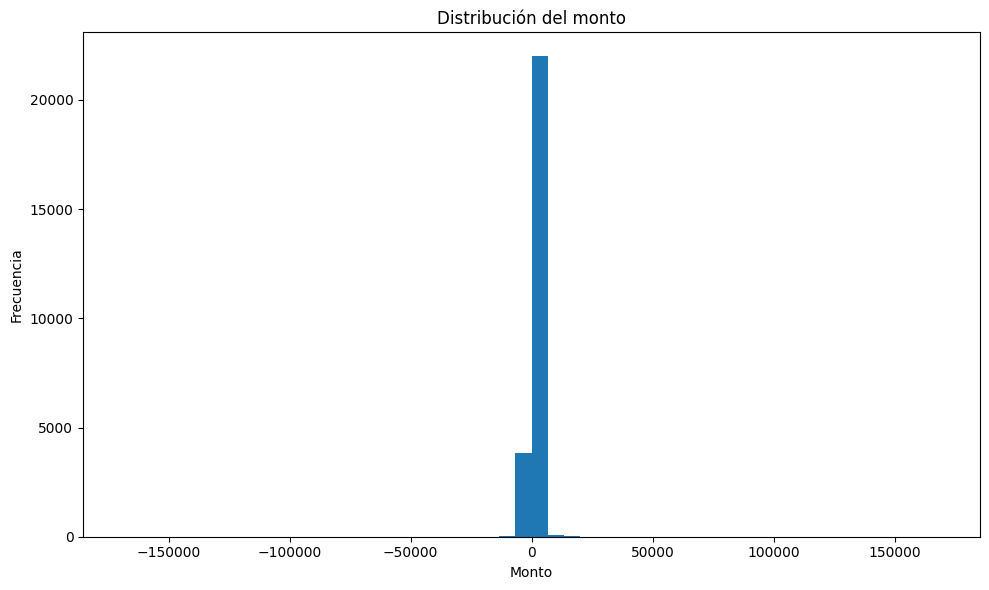

In [35]:
plt.figure(figsize=(10,6))
plt.hist(df["Monto"].dropna(), bins=50)
plt.title("Distribución del monto")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()